In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

2026-08-05 16:40:51.805494: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-05 16:40:51.983786: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
dataset_path = "../dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 5000 files belonging to 5 classes.
Using 4000 files for training.


In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 5000 files belonging to 5 classes.
Using 1000 files for validation.


In [5]:
class_names = train_ds.class_names

class_names = val_ds.class_names
print(class_names)

['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']


In [6]:
best_model = load_model("../models/resnet50_final.keras")

In [7]:
import os

print(os.path.getsize("../models/resnet50_best.keras"))

101330178


In [8]:
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,165,201 (96.00 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,051,660 (4.01 MB)

In [9]:
loss, accuracy = best_model.evaluate(val_ds)

print(f"Validation Loss : {loss:.4f}")
print(f"Validation Accuracy : {accuracy*100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.9820 - loss: 0.0528
Validation Loss : 0.0528
Validation Accuracy : 98.20%


In [10]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

2026-08-05 16:43:44.208914: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

2026-08-05 16:44:53.136237: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


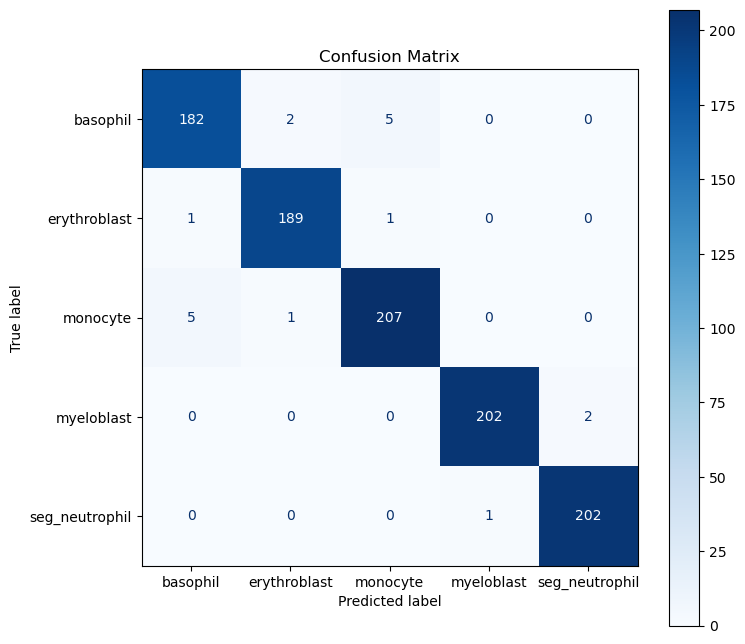

In [12]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [13]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                precision    recall  f1-score   support

      basophil       0.97      0.96      0.97       189
  erythroblast       0.98      0.99      0.99       191
      monocyte       0.97      0.97      0.97       213
    myeloblast       1.00      0.99      0.99       204
seg_neutrophil       0.99      1.00      0.99       203

      accuracy                           0.98      1000
     macro avg       0.98      0.98      0.98      1000
  weighted avg       0.98      0.98      0.98      1000



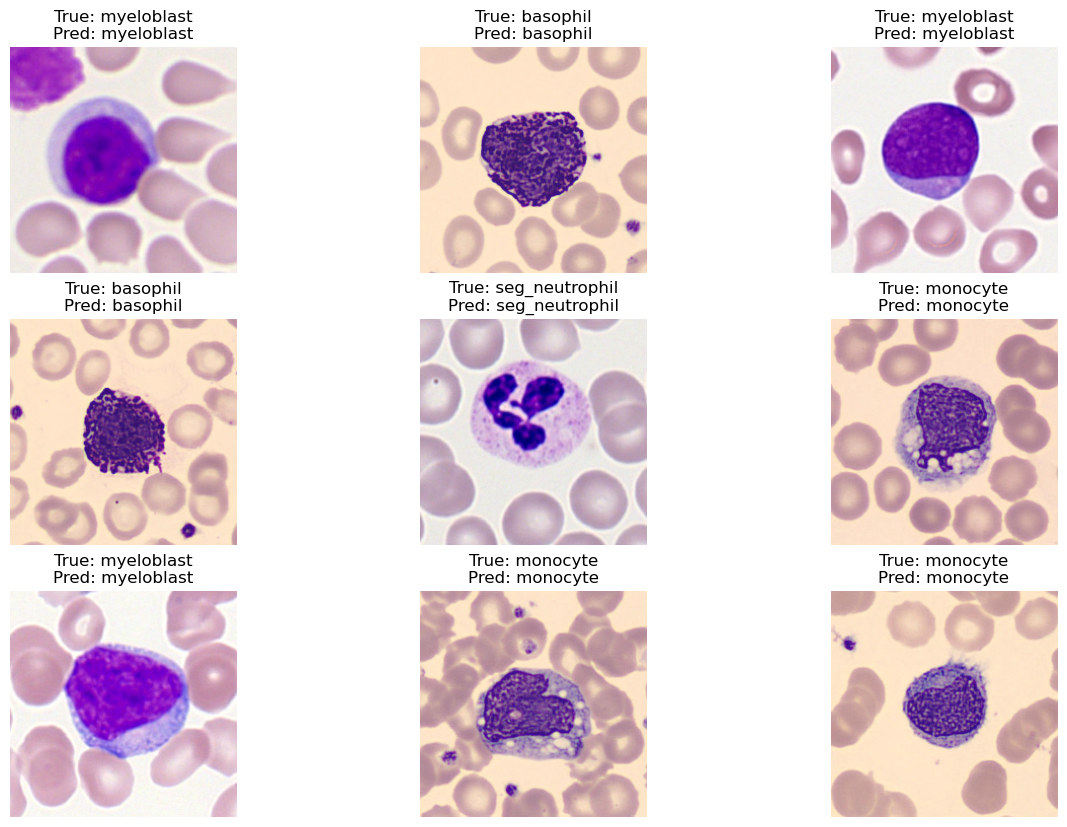

In [14]:
images, labels = next(iter(val_ds))

predictions = best_model.predict(images, verbose=0)
predicted = np.argmax(predictions, axis=1)

plt.figure(figsize=(15,10))

count = 0

for i in range(len(images)):

    if predicted[i] == labels[i]:

        plt.subplot(3,3,count+1)

        img = images[i].numpy()

        img = (img - img.min()) / (img.max() - img.min())

        plt.imshow(img)

        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[predicted[i]]}")

        plt.axis("off")

        count += 1

        if count == 9:
            break

plt.show()

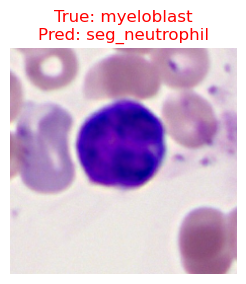

In [15]:
images, labels = next(iter(val_ds))

predictions = best_model.predict(images, verbose=0)
predicted = np.argmax(predictions, axis=1)

plt.figure(figsize=(15,10))

count = 0

for i in range(len(images)):

    if predicted[i] != labels[i]:

        plt.subplot(3,3,count+1)

        img = images[i].numpy()

        img = (img - img.min()) / (img.max() - img.min())

        plt.imshow(img)

        plt.title(
            f"True: {class_names[labels[i]]}\nPred: {class_names[predicted[i]]}",
            color="red"
        )

        plt.axis("off")

        count += 1

        if count == 9:
            break

plt.show()

In [16]:
results = {
    "Validation Accuracy": float(accuracy),
    "Validation Loss": float(loss)
}

with open("../models/evaluation_results.json", "w") as f:
    json.dump(results, f, indent=4)